In [1]:
!cd /root/dclip

/bin/bash: line 1: cd: /root/dclip: No such file or directory


In [ ]:
import os
import numpy as np
import pandas as pd

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision.transforms as T
from torchvision.datasets import VOCSegmentation
from PIL import Image

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

VOC_ROOT = "./data"
VOCSEG_ROOT = VOC_ROOT
VOC2007_ROOT = os.path.join(VOC_ROOT, "VOCdevkit", "VOC2007")

DCLIP_CKPT = os.path.join("checkpoints", "best_model_all_true_94.47.pth")
OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

VOC_CLASS_NAMES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]

print("VOCSEG_ROOT:", VOCSEG_ROOT)
print("VOC2007_ROOT:", VOC2007_ROOT, "| exists:", os.path.exists(VOC2007_ROOT))
print("DCLIP_CKPT:", DCLIP_CKPT, "| exists:", os.path.exists(DCLIP_CKPT))


DEVICE: cuda
VOCSEG_ROOT: ./data
VOC2007_ROOT: ./data/VOCdevkit/VOC2007 | exists: True
DCLIP_CKPT: checkpoints/best_model_FTT.pth | exists: True


In [3]:
metric_code = r'''
"""
metric_dclip.py

VOCSegmentation 기반 UnmixRate(= harmonic mean) 평가 유틸.

지원 model_type:
- "dclip"        : 당신 DCLIP 모델 객체 (models.DCLIP)
- "clip"         : OpenAI CLIP 모델 (RN50/RN101 등)
- "clip_surgery" : CLIP_Surgery 모델 (CS-RN101 등)

UnmixRate 정의:
    target_iou = IoU(target)
    neg_term   = 1 - mean( IoU(similar_negative_classes) )
    UnmixRate  = harmonic_mean(target_iou, neg_term)
"""

import os
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn.functional as F
import torchvision.transforms as T
from torchvision.datasets import VOCSegmentation

try:
    import clip as openai_clip
except Exception:
    openai_clip = None

try:
    from CLIP_Surgery import clip as CLIPS
except Exception:
    CLIPS = None


VOC_CLASS_NAMES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]


def get_device():
    return "cuda" if torch.cuda.is_available() else "cpu"


def minmax_uint8(x: np.ndarray) -> np.ndarray:
    x = x.astype(np.float32)
    if x.max() - x.min() < 1e-8:
        return np.zeros_like(x, dtype=np.uint8)
    x = (x - x.min()) / (x.max() - x.min())
    return (x * 255).astype(np.uint8)


def top_n_similar(target: str, sim_df: pd.DataFrame, n: int):
    sub = sim_df[sim_df["class"] == target].sort_values("cosine_similarity", ascending=False)
    out = []
    for _, r in sub.iterrows():
        other = r["other_class"]
        if other != target:
            out.append(other)
        if len(out) >= n:
            break
    return out


# ---------------------------------------------------------------------
# Text feature fns (for similarity CSV)
# ---------------------------------------------------------------------
def make_text_features_fn(model, model_type: str, device=None):
    """
    Returns a function: f(class_names) -> (K,D) numpy normalized features
    """
    device = device or get_device()
    model_type = str(model_type).lower()

    if model_type == "dclip":
        name_to_idx = {n: i for i, n in enumerate(model.class_names)}
        model.eval()

        @torch.no_grad()
        def _fn(class_names):
            feats = []
            for name in class_names:
                idx = name_to_idx[name]
                clip_feat = model.pos_text_features[idx:idx+1].to(device)   # (1,Dclip)
                proj = model.text_projector(clip_feat.float())              # (1,C)
                proj = F.normalize(proj, dim=-1)
                feats.append(proj.cpu().numpy())
            return np.concatenate(feats, axis=0)

        return _fn

    if model_type == "clip":
        if openai_clip is None:
            raise ImportError("openai clip이 필요합니다.")
        model.eval()

        @torch.no_grad()
        def _fn(class_names):
            prompts = [f"A photo of a {c}." for c in class_names]
            tok = openai_clip.tokenize(prompts).to(device)
            feats = model.encode_text(tok)
            feats = F.normalize(feats.float(), dim=-1).cpu().numpy()
            return feats

        return _fn

    if model_type == "clip_surgery":
        if CLIPS is None:
            raise ImportError("CLIP_Surgery가 필요합니다.")
        model.eval()

        @torch.no_grad()
        def _fn(class_names):
            feats = CLIPS.encode_text_with_prompt_ensemble(model, class_names, device)
            feats = feats / feats.norm(dim=-1, keepdim=True)
            return feats.float().cpu().numpy()

        return _fn

    raise ValueError("Unknown model_type: %s" % model_type)


def generate_similarity_csv(text_features_fn, model_name: str, out_dir="outputs"):
    os.makedirs(out_dir, exist_ok=True)
    out_csv = os.path.join(out_dir, "voc2007_class_similarity_sorted_%s.csv" % model_name.replace("/", "-"))

    if os.path.exists(out_csv):
        return out_csv

    feats = text_features_fn(VOC_CLASS_NAMES)
    feats = feats / (np.linalg.norm(feats, axis=1, keepdims=True) + 1e-12)
    sim = feats @ feats.T

    records = []
    for i, cls in enumerate(VOC_CLASS_NAMES):
        sims = sim[i]
        for j in np.argsort(sims):
            records.append({
                "class": cls,
                "other_class": VOC_CLASS_NAMES[j],
                "cosine_similarity": float(sims[j]),
            })

    df = pd.DataFrame.from_records(records).sort_values(["class", "cosine_similarity"], ascending=[True, True])
    df.to_csv(out_csv, index=False)
    return out_csv


# ---------------------------------------------------------------------
# CLIP local tokens (vanilla clip)
# ---------------------------------------------------------------------
def encode_clip_local_tokens(clip_model, images: torch.Tensor) -> torch.Tensor:
    """
    Returns local tokens: (B,HW,D)
    - ResNet: layer4 -> attnpool v_proj/c_proj (cls 제외)
    - ViT: patch tokens
    """
    visual = clip_model.visual
    is_resnet = hasattr(visual, "layer4")

    if is_resnet:
        def stem(x):
            for conv, bn in [(visual.conv1, visual.bn1), (visual.conv2, visual.bn2), (visual.conv3, visual.bn3)]:
                x = visual.relu(bn(conv(x)))
            x = visual.avgpool(x)
            return x

        x = images.type(visual.conv1.weight.dtype)
        x = stem(x)
        x = visual.layer1(x)
        x = visual.layer2(x)
        x = visual.layer3(x)
        x = visual.layer4(x)

        B, C, H, W = x.shape
        attnpool = visual.attnpool

        tokens = x.reshape(B, C, H * W).permute(2, 0, 1)  # (HW,B,C)
        tokens = torch.cat([tokens.mean(dim=0, keepdim=True), tokens], dim=0)  # (HW+1,B,C)

        pos_embed = attnpool.positional_embedding
        if pos_embed.shape[0] != H * W + 1:
            cls_pos = pos_embed[:1]
            spatial = pos_embed[1:]
            orig = int(spatial.shape[0] ** 0.5)
            spatial = spatial.permute(1, 0).reshape(1, -1, orig, orig)
            spatial = F.interpolate(spatial, size=(H, W), mode="bicubic", align_corners=False)
            spatial = spatial.reshape(-1, H * W).permute(1, 0)
            pos_embed = torch.cat([cls_pos, spatial], dim=0)

        tokens = tokens + pos_embed[:, None, :].to(tokens.dtype)
        tokens = F.linear(tokens, attnpool.v_proj.weight, attnpool.v_proj.bias)
        tokens = F.linear(tokens, attnpool.c_proj.weight, attnpool.c_proj.bias)

        tokens = tokens[1:].permute(1, 0, 2)  # (B,HW,D)
        return tokens

    # ViT
    x = images.type(visual.conv1.weight.dtype)
    x = visual.conv1(x)
    x = x.reshape(x.shape[0], x.shape[1], -1).permute(0, 2, 1)

    cls_tok = visual.class_embedding.to(x.dtype) + torch.zeros(
        x.shape[0], 1, x.shape[-1], dtype=x.dtype, device=x.device
    )
    x = torch.cat([cls_tok, x], dim=1)
    x = x + visual.positional_embedding.to(x.dtype)
    x = visual.ln_pre(x)

    x = x.permute(1, 0, 2)
    x = visual.transformer(x)
    x = x.permute(1, 0, 2)

    x = visual.ln_post(x)
    tokens = x[:, 1:, :]
    if visual.proj is not None:
        tokens = tokens @ visual.proj
    return tokens


# ---------------------------------------------------------------------
# Segmentation fns
# ---------------------------------------------------------------------
def make_segment_fn(model, model_type: str, image_size=448, device=None):
    """
    Returns:
        segment_fn(image_pil, target_class, negative_classes, threshold)->dict(name->bool mask)

    DCLIP: class별 (neg,pos) 2-way softmax의 P(pos)로 마스크 생성(정합)
    """
    device = device or get_device()
    model_type = str(model_type).lower()

    normalize = T.Normalize(
        mean=[0.48145466, 0.4578275, 0.40821073],
        std=[0.26862954, 0.26130258, 0.27577711],
    )

    if model_type == "dclip":
        preprocess = T.Compose([T.Resize((image_size, image_size)), T.ToTensor(), normalize])
        name_to_idx = {n: i for i, n in enumerate(model.class_names)}
        model.eval()

        @torch.no_grad()
        def _segment(image_pil, target_class, negative_classes, threshold=0.5, temp=5.0):
            classes = [target_class] + list(negative_classes)
            img = preprocess(image_pil.convert("RGB")).unsqueeze(0).to(device)

            img_local = model.clip.encode_image_local(img)              # (1,HW,Dclip)
            img_proj = model.image_projector(img_local.float())         # (1,HW,C)
            img_proj = F.normalize(img_proj, dim=-1)

            hw = img_proj.shape[1]
            h = int(np.sqrt(hw))
            w = hw // h
            if h * w != hw:
                h = w = int(hw ** 0.5)

            W0, H0 = image_pil.size  # (W,H)
            masks = {}

            for cname in classes:
                idx = name_to_idx[cname]
                pos_clip = model.pos_text_features[idx:idx+1].to(device)
                neg_clip = model.neg_text_features[idx:idx+1].to(device)

                pos = F.normalize(model.text_projector(pos_clip.float()), dim=-1)  # (1,C)
                neg = F.normalize(model.text_projector(neg_clip.float()), dim=-1)

                sim_pos = (img_proj @ pos.t()).squeeze(-1) * temp  # (1,HW)
                sim_neg = (img_proj @ neg.t()).squeeze(-1) * temp

                prob_pos = torch.softmax(torch.stack([sim_neg, sim_pos], dim=-1), dim=-1)[..., 1]  # (1,HW)

                m = prob_pos[0].reshape(h, w).detach().cpu().numpy()   # 0..1
                m = (m * 255).astype(np.uint8)
                m = np.array(Image.fromarray(m).resize((W0, H0), resample=Image.BICUBIC))
                masks[cname] = (m > int(255 * threshold))

            return masks

        return _segment

    if model_type == "clip":
        if openai_clip is None:
            raise ImportError("openai clip이 필요합니다.")
        preprocess = T.Compose([T.Resize((image_size, image_size)), T.ToTensor(), normalize])
        model.eval()

        @torch.no_grad()
        def _segment(image_pil, target_class, negative_classes, threshold=0.5):
            texts = [target_class] + list(negative_classes)
            prompts = [f"A photo of a {t}." for t in texts]

            img = preprocess(image_pil.convert("RGB")).unsqueeze(0).to(device)
            tokens = encode_clip_local_tokens(model, img)
            tokens = F.normalize(tokens.float(), dim=-1)

            tok = openai_clip.tokenize(prompts).to(device)
            text_feat = model.encode_text(tok)
            text_feat = F.normalize(text_feat.float(), dim=-1)

            sim = torch.matmul(tokens, text_feat.t())[0].cpu().numpy()  # (HW,N)
            hw = sim.shape[0]
            h = int(np.sqrt(hw))
            w = hw // h
            if h * w != hw:
                h = w = int(hw ** 0.5)

            W0, H0 = image_pil.size
            masks = {}
            for j, name in enumerate(texts):
                m = sim[:, j].reshape(h, w)
                m = minmax_uint8(m)
                m = np.array(Image.fromarray(m).resize((W0, H0), resample=Image.BICUBIC))
                masks[name] = (m > int(255 * threshold))
            return masks

        return _segment

    if model_type == "clip_surgery":
        if CLIPS is None:
            raise ImportError("CLIP_Surgery가 필요합니다.")

        preprocess = T.Compose([
            T.Resize((224, 224), interpolation=T.InterpolationMode.BICUBIC),
            T.ToTensor(),
            normalize,
        ])
        model.eval()

        @torch.no_grad()
        def _segment(image_pil, target_class, negative_classes, threshold=0.5):
            import cv2
            cv2_img = cv2.cvtColor(np.array(image_pil.convert("RGB")), cv2.COLOR_RGB2BGR)
            texts = [target_class] + list(negative_classes)

            img = preprocess(image_pil).unsqueeze(0).to(device)
            image_features = model.encode_image(img)
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)

            text_features = CLIPS.encode_text_with_prompt_ensemble(model, texts, device)
            similarity = CLIPS.clip_feature_surgery(image_features, text_features)
            similarity_map = CLIPS.get_similarity_map(similarity[:, 1:, :], cv2_img.shape[:2])  # (1,H,W,N)

            masks = {}
            for n, name in enumerate(texts):
                m = similarity_map[0, :, :, n].detach().cpu().numpy()
                m = minmax_uint8(m)
                masks[name] = (m > int(255 * threshold))
            return masks

        return _segment

    raise ValueError("Unknown model_type: %s" % model_type)


# ---------------------------------------------------------------------
# Main runner
# ---------------------------------------------------------------------
def run_unmixrate_voc2007(
    model,
    model_type: str,
    model_name: str,
    voc_root="datasets",
    year="2007",
    image_set="test",
    threshold=0.5,
    n_similar_negatives=5,
    max_images=200,
    out_dir="outputs",
    image_size=448,
):
    """
    Returns:
        df_results, avg_unmixrate, csv_path
    """
    device = get_device()
    os.makedirs(out_dir, exist_ok=True)

    text_fn = make_text_features_fn(model, model_type=model_type, device=device)
    sim_csv = generate_similarity_csv(text_fn, model_name=model_name, out_dir=out_dir)
    sim_df = pd.read_csv(sim_csv)

    seg_fn = make_segment_fn(model, model_type=model_type, image_size=image_size, device=device)

    voc = VOCSegmentation(root=voc_root, year=year, image_set=image_set, download=False)
    total = len(voc) if max_images is None else min(len(voc), int(max_images))

    results = []
    for i in range(total):
        image_pil, gt_mask_pil = voc[i]
        gt = np.array(gt_mask_pil, dtype=np.uint8)  # 0..20,255

        present = np.unique(gt).tolist()
        present = [p for p in present if p not in (0, 255)]
        if len(present) == 0:
            continue

        for cls_id in present:
            target_class = VOC_CLASS_NAMES[int(cls_id) - 1]
            negs = top_n_similar(target_class, sim_df, n_similar_negatives)
            if not negs:
                continue

            gt_mask = (gt == cls_id)
            masks = seg_fn(image_pil, target_class, negs, threshold=threshold)

            iou = {}
            for name, pmask in masks.items():
                pmask = pmask.astype(bool)
                inter = np.logical_and(gt_mask, pmask).sum()
                union = np.logical_or(gt_mask, pmask).sum()
                iou[name] = float(inter / union) if union > 0 else 0.0

            neg_ious = [iou[n] for n in negs if n in iou]
            neg_term = 1.0 - float(np.mean(neg_ious)) if len(neg_ious) else 0.0

            tgt = iou.get(target_class, 0.0)
            if tgt > 0 and neg_term > 0:
                unmix = 2.0 / ((1.0 / tgt) + (1.0 / neg_term))
            else:
                unmix = 0.0

            results.append({
                "image_id": os.path.basename(voc.images[i]).split(".")[0],
                "target_class": target_class,
                "target_iou": tgt,
                "neg_term": neg_term,
                "unmixrate": unmix,
                "negs": ",".join(negs),
            })

    df = pd.DataFrame(results)
    avg = float(df["unmixrate"].mean()) if len(df) else 0.0

    out_csv = os.path.join(
        out_dir,
        "unmixrate_%s_%s_%s_thr%s_N%s_avg%.4f.csv" % (
            year,
            image_set,
            model_name.replace("/", "-"),
            threshold,
            n_similar_negatives,
            avg
        )
    )
    df.to_csv(out_csv, index=False)
    return df, avg, out_csv
'''
with open("metric_dclip.py", "w", encoding="utf-8") as f:
    f.write(metric_code)

import importlib
import metric_dclip
importlib.reload(metric_dclip)

from metric_dclip import run_unmixrate_voc2007
print("metric_dclip.py written & imported OK")


metric_dclip.py written & imported OK


/root/DCLIP/CLIP_Surgery/clip/clip.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging


In [4]:
# ---- DCLIP ----
from models import create_dclip_model
from utils import load_checkpoint

dclip_model = create_dclip_model(
    clip_model_name="RN101",
    class_names=VOC_CLASS_NAMES,
    num_classes=len(VOC_CLASS_NAMES),
    proj_dim=256,
    text_hidden_dim=384,
    aggregation_scale=5.0,
    device=DEVICE,
)

if os.path.exists(DCLIP_CKPT):
    dclip_model = load_checkpoint(dclip_model, DCLIP_CKPT, device=DEVICE)
else:
    print("[WARN] DCLIP checkpoint not found -> head is random (mAP meaningless).")

dclip_model.eval()


# ---- OpenAI CLIP (RN50 / RN101) ----
import clip as openai_clip
clip_rn50, clip_pre_rn50 = openai_clip.load("RN50", device=DEVICE, jit=False)
clip_rn101, clip_pre_rn101 = openai_clip.load("RN101", device=DEVICE, jit=False)
clip_rn50.eval(); clip_rn101.eval()
print("Loaded CLIP RN50/RN101")


# ---- CLIP Surgery (CS-RN101) ----
try:
    from CLIP_Surgery import clip as CLIPS
    cs_rn101, _ = CLIPS.load("CS-RN101", device=DEVICE)
    cs_rn101.eval()
    print("Loaded CLIP Surgery CS-RN101")
except Exception as e:
    cs_rn101 = None
    print("[WARN] CLIP Surgery load failed:", repr(e))


Loaded CLIP RN50/RN101
Loaded CLIP Surgery CS-RN101


In [5]:
from dataset import VOC2007Dataset
from utils import compute_map

@torch.no_grad()
def eval_map_dclip(model, voc2007_root, batch_size=64, num_workers=4):
    model.eval()
    ds = VOC2007Dataset(
        root=voc2007_root,
        split="test",
        image_size=448,
        use_cutout=False,
        use_randaugment=False,
    )
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    ys, ps, ms = [], [], []
    for images, labels, mask in dl:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        mask   = mask.to(DEVICE, non_blocking=True)

        logits = model(images, return_features=False)
        prob   = F.softmax(logits, dim=1)[:, 1, :]

        ys.append(labels.cpu().numpy())
        ps.append(prob.cpu().numpy())
        ms.append(mask.cpu().numpy())

    return compute_map(np.concatenate(ys, 0), np.concatenate(ps, 0), y_mask=np.concatenate(ms, 0))


@torch.no_grad()
def eval_map_clip_like(clip_model, voc2007_root, preprocess, batch_size=64, num_workers=4, prompt="A photo of a {}."):
    clip_model.eval()
    ds = VOC2007Dataset(
        root=voc2007_root,
        split="test",
        transform=preprocess,
        use_cutout=False,
        use_randaugment=False,
    )
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    texts = [prompt.format(c) for c in VOC_CLASS_NAMES]
    tok = openai_clip.tokenize(texts).to(DEVICE)
    tf = clip_model.encode_text(tok)
    tf = tf / tf.norm(dim=-1, keepdim=True)

    ys, ss, ms = [], [], []
    for images, labels, mask in dl:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        mask   = mask.to(DEVICE, non_blocking=True)

        imf = clip_model.encode_image(images)
        imf = imf / imf.norm(dim=-1, keepdim=True)

        score = (imf @ tf.T).float()

        ys.append(labels.cpu().numpy())
        ss.append(score.cpu().numpy())
        ms.append(mask.cpu().numpy())

    return compute_map(np.concatenate(ys, 0), np.concatenate(ss, 0), y_mask=np.concatenate(ms, 0))


@torch.no_grad()
def eval_map_clip_surgery(cs_model, voc2007_root, batch_size=64, num_workers=4, score_mode="surgery_max"):
    if cs_model is None:
        return float("nan")
    cs_model.eval()

    cs_transform = T.Compose([
        T.Resize((224, 224), interpolation=T.InterpolationMode.BICUBIC),
        T.ToTensor(),
        T.Normalize((0.48145466, 0.4578275, 0.40821073),
                    (0.26862954, 0.26130258, 0.27577711)),
    ])

    ds = VOC2007Dataset(
        root=voc2007_root,
        split="test",
        transform=cs_transform,
        use_cutout=False,
        use_randaugment=False,
    )
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    tf = CLIPS.encode_text_with_prompt_ensemble(cs_model, VOC_CLASS_NAMES, DEVICE)
    if tf.dim() == 3: tf = tf[0]
    tf = tf / tf.norm(dim=-1, keepdim=True)

    redundant = CLIPS.encode_text_with_prompt_ensemble(cs_model, [""], DEVICE)
    if redundant.dim() == 3: redundant = redundant[0]
    redundant = redundant / redundant.norm(dim=-1, keepdim=True)

    ys, ss, ms = [], [], []
    for images, labels, mask in dl:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        mask   = mask.to(DEVICE, non_blocking=True)

        imf = cs_model.encode_image(images)
        imf = imf / imf.norm(dim=-1, keepdim=True)

        if score_mode in ("surgery_max", "surgery_mean"):
            sim = CLIPS.clip_feature_surgery(imf, tf, redundant)
            if sim.dim() == 2:
                score = sim
            else:
                spatial = sim[:, 1:, :]
                score = spatial.max(dim=1).values if score_mode == "surgery_max" else spatial.mean(dim=1)
        else:
            pooled = imf[:, 0, :] if (imf.dim() == 3 and score_mode == "cls") else imf[:, 1:, :].mean(dim=1)
            pooled = pooled / pooled.norm(dim=-1, keepdim=True)
            score = (pooled @ tf.T).float()

        ys.append(labels.cpu().numpy())
        ss.append(score.float().cpu().numpy())
        ms.append(mask.cpu().numpy())

    return compute_map(np.concatenate(ys, 0), np.concatenate(ss, 0), y_mask=np.concatenate(ms, 0))


In [6]:
import importlib
import metric_dclip
importlib.reload(metric_dclip)

_old_make_segment_fn = metric_dclip.make_segment_fn

def _infer_hw_tokens(hw: int):
    h = int(np.sqrt(hw))
    w = hw // h
    if h * w != hw:
        h = w = int(round(np.sqrt(hw)))
    return h, w

def make_segment_fn_dclip_surgery(model, model_type: str, image_size=448, device=None):
    device = device or metric_dclip.get_device()
    model_type = str(model_type).lower()

    if model_type != "dclip":
        return _old_make_segment_fn(model, model_type=model_type, image_size=image_size, device=device)

    normalize = T.Normalize(
        mean=[0.48145466, 0.4578275, 0.40821073],
        std=[0.26862954, 0.26130258, 0.27577711],
    )
    preprocess = T.Compose([T.Resize((image_size, image_size)), T.ToTensor(), normalize])

    name_to_idx = {n: i for i, n in enumerate(model.class_names)}
    model.eval()

    @torch.no_grad()
    def _segment(image_pil, target_class, negative_classes, threshold=0.5, tau_surgery=2.0):
        classes = [target_class] + list(negative_classes)
        img_rgb = image_pil.convert("RGB")
        img = preprocess(img_rgb).unsqueeze(0).to(device)

        img_local = model.clip.encode_image_local(img)
        img_proj  = model.image_projector(img_local.float())
        img_proj  = F.normalize(img_proj, dim=-1)

        Fi = img_proj[0]
        hw = Fi.shape[0]
        h, w = _infer_hw_tokens(hw)

        Ft_list = []
        for cname in classes:
            idx = name_to_idx[cname]
            pos_clip = model.pos_text_features[idx:idx+1].to(device)
            pos = model.text_projector(pos_clip.float())
            Ft_list.append(F.normalize(pos, dim=-1))
        Ft = torch.cat(Ft_list, dim=0)
        N = Ft.shape[0]

        Fc = F.normalize(Fi.mean(dim=0, keepdim=True), dim=-1)
        s  = torch.softmax(tau_surgery * (Fc @ Ft.t()), dim=-1)
        wv = (s / (s.mean(dim=-1, keepdim=True) + 1e-8)).squeeze(0)

        Fm = Fi[:, None, :] * Ft[None, :, :]
        Fr = (Fm * wv[None, :, None]).mean(dim=1)
        S  = (Fm - Fr[:, None, :]).sum(dim=-1)
        S  = F.relu(S)

        W0, H0 = img_rgb.size
        masks = {}
        for j, cname in enumerate(classes):
            m = S[:, j].reshape(h, w).detach().cpu().numpy()
            m = metric_dclip.minmax_uint8(m)
            m = np.array(Image.fromarray(m).resize((W0, H0), resample=Image.BICUBIC))
            masks[cname] = (m > int(255 * threshold))
        return masks

    return _segment

metric_dclip.make_segment_fn = make_segment_fn_dclip_surgery
from metric_dclip import run_unmixrate_voc2007
print("[OK] DCLIP UnmixRate mask patched -> Surgery (projected space).")


[OK] DCLIP UnmixRate mask patched -> Surgery (projected space).


In [7]:
UNMIX_YEAR = "2007"
UNMIX_SPLIT = "val"
THR_UNMIX = 0.5
N_NEG = 5
MAX_IMAGES_UNMIX = None

def run_unmix(model, model_type, model_name, thr=0.5, N=5, max_images=None, year="2007", image_set="val"):
    imsz = 448 if str(model_type).lower() == "dclip" else 224
    return run_unmixrate_voc2007(
        model=model,
        model_type=model_type,
        model_name=model_name,
        voc_root=VOCSEG_ROOT,
        year=year,
        image_set=image_set,
        threshold=thr,
        n_similar_negatives=N,
        max_images=max_images,
        out_dir=OUT_DIR,
        image_size=imsz,
    )

print("VOCSeg size:", len(VOCSegmentation(root=VOCSEG_ROOT, year=UNMIX_YEAR, image_set=UNMIX_SPLIT, download=False)))


VOCSeg size: 213


In [8]:
# --- mAP ---
map_dclip = eval_map_dclip(dclip_model, VOC2007_ROOT)
map_rn50  = eval_map_clip_like(clip_rn50,  VOC2007_ROOT, preprocess=clip_pre_rn50)
map_rn101 = eval_map_clip_like(clip_rn101, VOC2007_ROOT, preprocess=clip_pre_rn101)

map_cs_cls      = eval_map_clip_surgery(cs_rn101, VOC2007_ROOT, score_mode="cls")
map_cs_mean     = eval_map_clip_surgery(cs_rn101, VOC2007_ROOT, score_mode="mean")
map_cs_surg_max = eval_map_clip_surgery(cs_rn101, VOC2007_ROOT, score_mode="surgery_max")
map_cs_surg_mean= eval_map_clip_surgery(cs_rn101, VOC2007_ROOT, score_mode="surgery_mean")
map_cs = map_cs_surg_max

print("mAP:", {
    "DCLIP-RN101": map_dclip,
    "CLIP-RN50": map_rn50,
    "CLIP-RN101": map_rn101,
    "CS-RN101(cls)": map_cs_cls,
    "CS-RN101(mean)": map_cs_mean,
    "CS-RN101(surg_max)": map_cs_surg_max,
    "CS-RN101(surg_mean)": map_cs_surg_mean,
})


# --- UnmixRate (Segmentation val) ---
_, unmix_dclip, csv_dclip = run_unmix(dclip_model, "dclip", "DCLIP-RN101",
                                     thr=THR_UNMIX, N=N_NEG, max_images=MAX_IMAGES_UNMIX,
                                     year=UNMIX_YEAR, image_set=UNMIX_SPLIT)
_, unmix_rn50,  csv_rn50  = run_unmix(clip_rn50,  "clip",  "CLIP-RN50",
                                     thr=THR_UNMIX, N=N_NEG, max_images=MAX_IMAGES_UNMIX,
                                     year=UNMIX_YEAR, image_set=UNMIX_SPLIT)
_, unmix_rn101, csv_rn101 = run_unmix(clip_rn101, "clip",  "CLIP-RN101",
                                     thr=THR_UNMIX, N=N_NEG, max_images=MAX_IMAGES_UNMIX,
                                     year=UNMIX_YEAR, image_set=UNMIX_SPLIT)
if cs_rn101 is not None:
    _, unmix_cs, csv_cs = run_unmix(cs_rn101, "clip_surgery", "CLIPSurgery-CS-RN101",
                                    thr=THR_UNMIX, N=N_NEG, max_images=MAX_IMAGES_UNMIX,
                                    year=UNMIX_YEAR, image_set=UNMIX_SPLIT)
else:
    unmix_cs, csv_cs = float("nan"), ""

df_summary = pd.DataFrame([
    {"model":"DCLIP-RN101",          "mAP":map_dclip, "UnmixRate":unmix_dclip, "unmix_csv":csv_dclip},
    {"model":"CLIP-RN50",            "mAP":map_rn50,  "UnmixRate":unmix_rn50,  "unmix_csv":csv_rn50},
    {"model":"CLIP-RN101",           "mAP":map_rn101, "UnmixRate":unmix_rn101, "unmix_csv":csv_rn101},
    {"model":"CLIPSurgery-CS-RN101", "mAP":map_cs,    "UnmixRate":unmix_cs,    "unmix_csv":csv_cs},
]).sort_values("mAP", ascending=False)

df_summary


Loaded VOC2007 test: 4952 images | avg valid-label ratio: 0.994


Loaded VOC2007 test: 4952 images | avg valid-label ratio: 0.994
Loaded VOC2007 test: 4952 images | avg valid-label ratio: 0.994
Loaded VOC2007 test: 4952 images | avg valid-label ratio: 0.994
Loaded VOC2007 test: 4952 images | avg valid-label ratio: 0.994
Loaded VOC2007 test: 4952 images | avg valid-label ratio: 0.994
Loaded VOC2007 test: 4952 images | avg valid-label ratio: 0.994
mAP: {'DCLIP-RN101': 93.87843618395418, 'CLIP-RN50': 76.54066297147138, 'CLIP-RN101': 77.34501053786505, 'CS-RN101(cls)': 67.3037401258931, 'CS-RN101(mean)': 68.28495501532268, 'CS-RN101(surg_max)': 84.89495402359975, 'CS-RN101(surg_mean)': 77.08234718884097}


,model,mAP,UnmixRate,unmix_csv
0,DCLIP-RN101,93.878436,0.503687,outputs/unmixrate_2007_val_DCLIP-RN101_thr0.5_...
3,CLIPSurgery-CS-RN101,84.894954,0.418721,outputs/unmixrate_2007_val_CLIPSurgery-CS-RN10...
2,CLIP-RN101,77.345011,0.314741,outputs/unmixrate_2007_val_CLIP-RN101_thr0.5_N...
1,CLIP-RN50,76.540663,0.298042,outputs/unmixrate_2007_val_CLIP-RN50_thr0.5_N5...


In [9]:
def inspect_unmix_csv(path):
    if not path or (not os.path.exists(path)):
        return None
    df = pd.read_csv(path)
    return {
        "rows": len(df),
        "target_iou_mean": float(df["target_iou"].mean()) if len(df) else 0.0,
        "neg_term_mean": float(df["neg_term"].mean()) if len(df) else 0.0,
        "unmix_mean": float(df["unmixrate"].mean()) if len(df) else 0.0,
    }

inspect = pd.DataFrame([
    {"model":"DCLIP-RN101",          **(inspect_unmix_csv(csv_dclip) or {})},
    {"model":"CLIP-RN50",            **(inspect_unmix_csv(csv_rn50) or {})},
    {"model":"CLIP-RN101",           **(inspect_unmix_csv(csv_rn101) or {})},
    {"model":"CLIPSurgery-CS-RN101", **(inspect_unmix_csv(csv_cs) or {})},
])
inspect


,model,rows,target_iou_mean,neg_term_mean,unmix_mean
0,DCLIP-RN101,344,0.368121,0.978962,0.503687
1,CLIP-RN50,344,0.220487,0.918485,0.298042
2,CLIP-RN101,344,0.259473,0.814632,0.314741
3,CLIPSurgery-CS-RN101,344,0.324694,0.915052,0.418721


,case,mIoU(target_iou) ↑,mean_neg_iou(leakage) ↓,neg_term(=1-leakage) ↑,UnmixRate(HM) ↑
1,B: mIoU 약간↓ + leakage 거의 없음 (UnmixRate↑),0.850024,0.020005,0.979995,0.910394
2,C: mIoU 중간 + leakage 중간,0.600024,0.200047,0.799953,0.685712
0,A: mIoU 높음 + leakage 큼 (UnmixRate↓),1.000000,0.600024,0.399976,0.571404


UnmixRate는 mIoU만 보는 게 아니라, 유사 클래스 leakage까지 같이 보고(조화평균) 둘 다 잘해야 점수가 나옵니다.


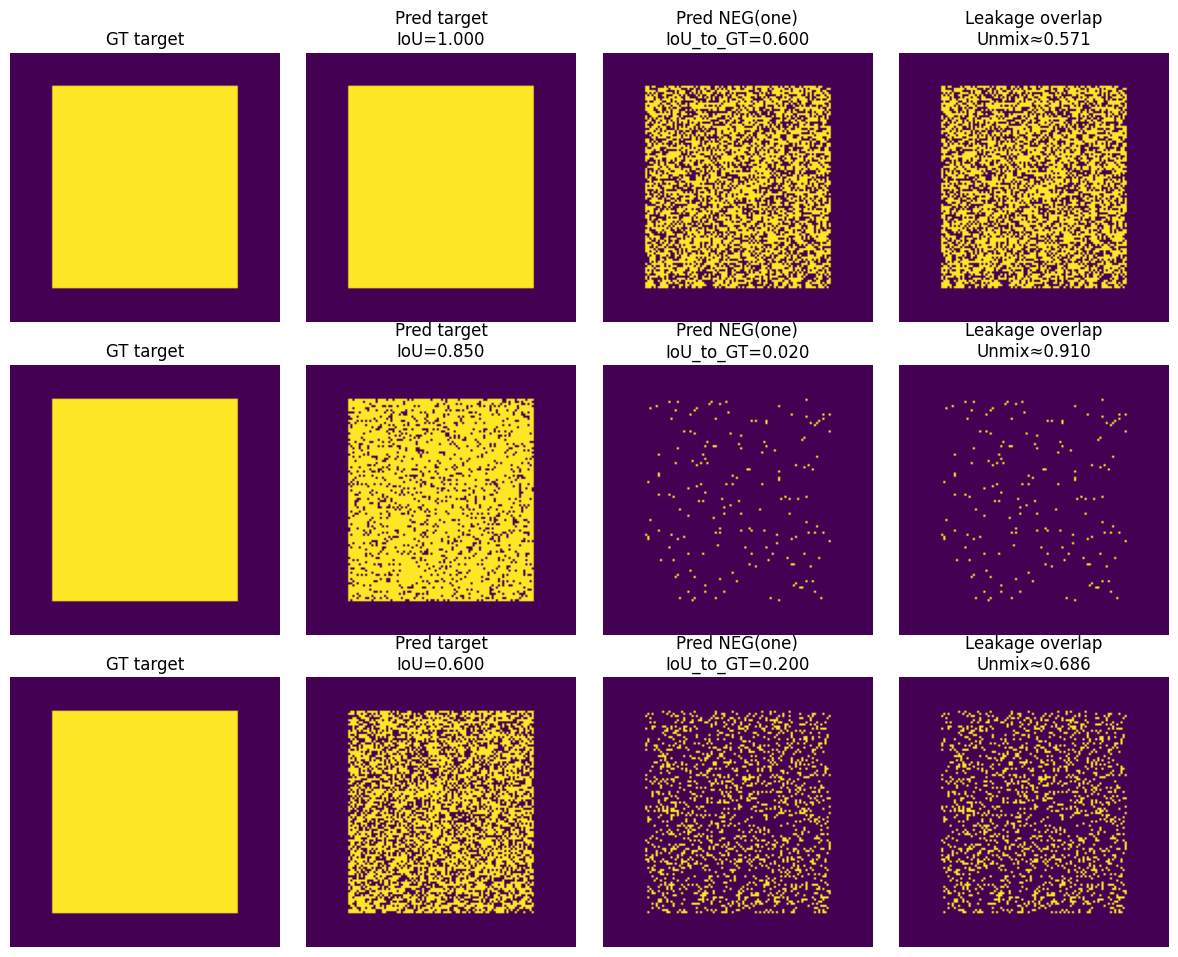

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def iou(a: np.ndarray, b: np.ndarray) -> float:
    a = a.astype(bool); b = b.astype(bool)
    inter = np.logical_and(a, b).sum()
    uni   = np.logical_or(a, b).sum()
    return float(inter / uni) if uni > 0 else 0.0

def harmonic_mean(x, y, eps=1e-12):
    x = float(x); y = float(y)
    if x <= 0 or y <= 0:
        return 0.0
    return float(2.0 / ((1.0/(x+eps)) + (1.0/(y+eps))))

def unmixrate(gt_target, pred_target, pred_negs):
    tgt_iou = iou(gt_target, pred_target)
    neg_ious = [iou(gt_target, n) for n in pred_negs]
    mean_neg_iou = float(np.mean(neg_ious)) if len(neg_ious) else 0.0
    neg_term = 1.0 - mean_neg_iou
    return tgt_iou, neg_term, harmonic_mean(tgt_iou, neg_term), mean_neg_iou

rng = np.random.default_rng(0)

def subset_of_gt(gt_mask: np.ndarray, area_ratio: float) -> np.ndarray:
    area_ratio = float(np.clip(area_ratio, 0.0, 1.0))
    idx = np.flatnonzero(gt_mask.reshape(-1))
    if len(idx) == 0:
        return np.zeros_like(gt_mask, dtype=bool)
    k = int(round(len(idx) * area_ratio))
    pick = rng.choice(idx, size=max(0, k), replace=False) if k > 0 else np.array([], dtype=int)
    out = np.zeros(gt_mask.size, dtype=bool)
    out[pick] = True
    return out.reshape(gt_mask.shape)

H, W = 128, 128
gt = np.zeros((H, W), dtype=bool)
gt[16:112, 20:108] = True

cases = {
    # IoU는 최고인데, negative가 GT랑 크게 겹쳐서 UnmixRate는 깎이는 경우
    "A: mIoU 높음 + leakage 큼 (UnmixRate↓)": dict(target_ratio=1.00, neg_ratio=0.60, n_negs=5),
    # IoU는 약간 낮지만, leakage가 거의 없어서 UnmixRate가 더 나아질 수 있는 경우
    "B: mIoU 약간↓ + leakage 거의 없음 (UnmixRate↑)": dict(target_ratio=0.85, neg_ratio=0.02, n_negs=5),
    "C: mIoU 중간 + leakage 중간": dict(target_ratio=0.60, neg_ratio=0.20, n_negs=5),
}

records, viz = [], {}
for name, cfg in cases.items():
    pred_t = gt.copy() if cfg["target_ratio"] >= 0.999 else subset_of_gt(gt, cfg["target_ratio"])
    pred_negs = [subset_of_gt(gt, cfg["neg_ratio"]) for _ in range(cfg["n_negs"])]
    tgt_iou, neg_term, unmix, mean_neg_iou = unmixrate(gt, pred_t, pred_negs)

    records.append({
        "case": name,
        "mIoU(target_iou) ↑": tgt_iou,
        "mean_neg_iou(leakage) ↓": mean_neg_iou,
        "neg_term(=1-leakage) ↑": neg_term,
        "UnmixRate(HM) ↑": unmix,
    })
    viz[name] = (pred_t, pred_negs[0])

df = pd.DataFrame(records).sort_values("UnmixRate(HM) ↑", ascending=False)
display(df)

print("======")
print("UnmixRate는 mIoU만 보는 게 아니라, 유사 클래스 leakage까지 같이 보고(조화평균) 둘 다 잘해야 점수가 나옵니다.")

fig, axes = plt.subplots(len(cases), 4, figsize=(12, 3.2 * len(cases)))
for r, (name, cfg) in enumerate(cases.items()):
    pred_t, pred_neg0 = viz[name]
    tgt_iou, neg_term, unmix, mean_neg_iou = unmixrate(gt, pred_t, [pred_neg0])

    axes[r, 0].imshow(gt, vmin=0, vmax=1); axes[r, 0].set_title("GT target"); axes[r, 0].axis("off")
    axes[r, 1].imshow(pred_t, vmin=0, vmax=1); axes[r, 1].set_title(f"Pred target\nIoU={tgt_iou:.3f}"); axes[r, 1].axis("off")
    axes[r, 2].imshow(pred_neg0, vmin=0, vmax=1); axes[r, 2].set_title(f"Pred NEG(one)\nIoU_to_GT={mean_neg_iou:.3f}"); axes[r, 2].axis("off")

    overlap = np.logical_and(gt, pred_neg0)
    axes[r, 3].imshow(overlap, vmin=0, vmax=1)
    axes[r, 3].set_title(f"Leakage overlap\nUnmix≈{unmix:.3f}")
    axes[r, 3].axis("off")

plt.tight_layout()
plt.show()